<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 2.3: Joint Distributions and Random Samples

Rodrigo Vianna | 9/27/2026

In [26]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(423)
np.set_printoptions(precision=4, suppress=True)

## 2.3.1 Joint Probability Distributions
A joint probability distribution describes the probabilities of two random variables occurring together.

For discrete random variables \(X\) and \(Y\), the joint probability mass function is written as

$
P(X=x,Y=y)
$

The marginal probability distributions are found by summing the rows or columns of the joint distribution:

$
P(X=x)=\sum_y P(X=x,Y=y)
$  and  $
P(Y=y)=\sum_x P(X=x,Y=y)
$

In [27]:
x_values = np.array([0, 1, 2])
y_values = np.array([0, 1, 2])

# Marginal probability distributions
x_marginal = np.array([0.20, 0.40, 0.40])
y_marginal = np.array([0.20, 0.40, 0.40])

# Create a joint PMF for independent X and Y:
# P(X = x, Y = y) = P(X = x)P(Y = y)
joint_pmf = np.outer(x_marginal, y_marginal)

# Recover the marginals by summing rows and columns
marginal_x = np.sum(joint_pmf, axis=1)
marginal_y = np.sum(joint_pmf, axis=0)

print("Joint probability distribution:")
print(joint_pmf)

print("\nTotal probability:")
print(np.sum(joint_pmf))

print("\nMarginal distribution of X:")
for x, probability in zip(x_values, marginal_x):
    print(f"P(X = {x}) = {probability:.2f}")

print("\nMarginal distribution of Y:")
for y, probability in zip(y_values, marginal_y):
    print(f"P(Y = {y}) = {probability:.2f}")

# Example event probabilities
p_x_ge_1_and_y_ge_1 = np.sum(joint_pmf[1:, 1:])
p_y_2_given_x_1 = joint_pmf[1, 2] / marginal_x[1]

print("\nP(X ≥ 1 and Y ≥ 1) =", p_x_ge_1_and_y_ge_1)
print("P(Y = 2 | X = 1) =", p_y_2_given_x_1)

# Test whether X and Y are independent
p_x_1_and_y_1 = joint_pmf[1, 1]
product_of_marginals = marginal_x[1] * marginal_y[1]

print("\nP(X = 1 and Y = 1) =", p_x_1_and_y_1)
print("P(X = 1)P(Y = 1) =", product_of_marginals)
print("Are X and Y independent?",
      np.isclose(p_x_1_and_y_1, product_of_marginals))

Joint probability distribution:
[[0.04 0.08 0.08]
 [0.08 0.16 0.16]
 [0.08 0.16 0.16]]

Total probability:
1.0

Marginal distribution of X:
P(X = 0) = 0.20
P(X = 1) = 0.40
P(X = 2) = 0.40

Marginal distribution of Y:
P(Y = 0) = 0.20
P(Y = 1) = 0.40
P(Y = 2) = 0.40

P(X ≥ 1 and Y ≥ 1) = 0.6400000000000001
P(Y = 2 | X = 1) = 0.4

P(X = 1 and Y = 1) = 0.16000000000000003
P(X = 1)P(Y = 1) = 0.16000000000000006
Are X and Y independent? True


This code creates a joint probability distribution for the discrete random variables \(X\) and \(Y\). The rows represent possible values of \(X\), while the columns represent possible values of \(Y\). The marginal distributions are found by summing each row or column. The code also calculates an event probability, a conditional probability, and tests whether \(X\) and \(Y\) are independent.

In this example, the joint distribution is created by multiplying the marginal probabilities:

$
P(X=x,Y=y)=P(X=x)P(Y=y).
$

Therefore, \(X\) and \(Y\) are independent, and the final check should return `True`.

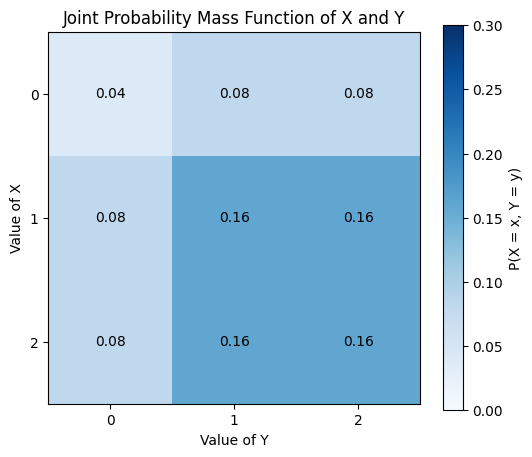

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(joint_pmf, cmap="Blues", vmin=0, vmax=0.30)

for row in range(joint_pmf.shape[0]):
    for column in range(joint_pmf.shape[1]):
        ax.text(
            column,
            row,
            f"{joint_pmf[row, column]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

ax.set_xticks(range(len(y_values)))
ax.set_yticks(range(len(x_values)))
ax.set_xticklabels(y_values)
ax.set_yticklabels(x_values)

ax.set_xlabel("Value of Y")
ax.set_ylabel("Value of X")
ax.set_title("Joint Probability Mass Function of X and Y")

plt.colorbar(image, label="P(X = x, Y = y)")
plt.show()

### Section Conclusion

This section showed how a joint probability distribution can describe the probabilities of two random variables at the same time. The marginal distributions were found by adding the rows and columns of the joint probability table. I also verified that $X$ and $Y$ were independent because the joint probability was equal to the product of their individual probabilities.

## 2.3.2 Correlation and Dependence
Correlation measures the direction and strength of a linear relationship between two variables. The Pearson correlation coefficient is

$$\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}
{\sigma_X\sigma_Y}$$

A correlation near 1 indicates a strong positive linear relationship, while a correlation near -1 indicates a strong negative linear relationship.

It is important to note that zero correlation does not always mean that two variables are independent. A nonlinear relationship can show strong dependence even when its linear correlation is near zero.

In [29]:
# Example of strong positive linear correlation
x_linear = np.arange(1, 11, dtype=float)
y_linear = np.array([
    2.4, 4.3, 6.2, 8.5, 9.8,
    12.4, 13.7, 16.2, 17.5, 20.4
])

linear_covariance = np.cov(x_linear, y_linear, ddof=0)[0, 1]
linear_correlation = np.corrcoef(x_linear, y_linear)[0, 1]

# Example of dependence with nearly zero linear correlation
x_nonlinear = np.linspace(-3, 3, 200)
y_nonlinear = x_nonlinear**2

nonlinear_correlation = np.corrcoef(x_nonlinear, y_nonlinear)[0, 1]

print("Positive linear relationship:")
print("Covariance =", linear_covariance)
print("Correlation =", linear_correlation)

print("\nNonlinear dependent relationship:")
print("Correlation =", nonlinear_correlation)
print("Although correlation is near zero, Y is determined by X².")

Positive linear relationship:
Covariance = 16.13
Correlation = 0.9985476221117504

Nonlinear dependent relationship:
Correlation = -1.9203276205777008e-16
Although correlation is near zero, Y is determined by X².


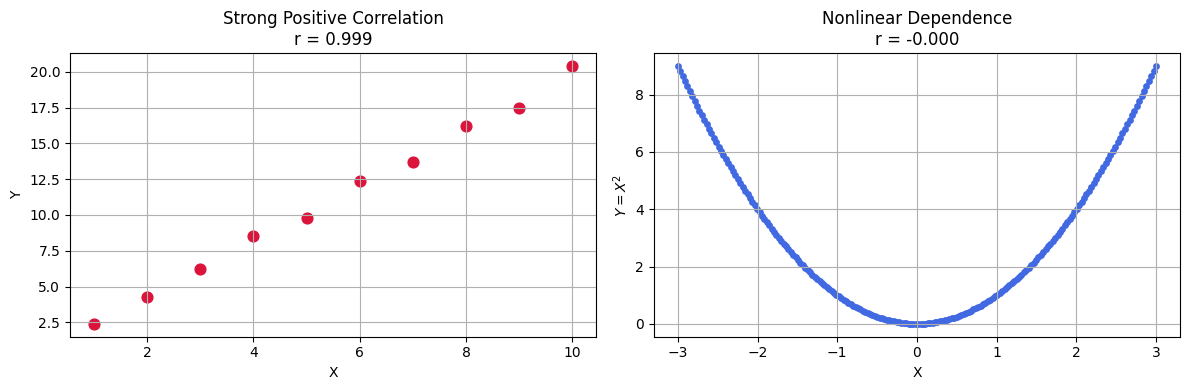

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_linear, y_linear, color="crimson", s=60)
axes[0].set_title(
    f"Strong Positive Correlation\nr = {linear_correlation:.3f}"
)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid()

axes[1].scatter(x_nonlinear, y_nonlinear, color="royalblue", s=15)
axes[1].set_title(
    f"Nonlinear Dependence\nr = {nonlinear_correlation:.3f}"
)
axes[1].set_xlabel("X")
axes[1].set_ylabel(r"$Y=X^2$")
axes[1].grid()

plt.tight_layout()
plt.show()

The first graph shows a strong positive linear relationship because the points increase together and the correlation is close to 1. The second graph shows that a correlation near 0 does not always mean that the variables are independent. In the nonlinear example, $Y = X^2$, so $Y$ still depends on $X$ even though there is no strong linear relationship.

### Section Conclusion

The first graph had a strong positive correlation because the values of $X$ and $Y$ increased together. The second graph was interesting because it showed that a correlation close to 0 does not always mean that the variables are independent, meaning correlation only measures a linear relationship between two variables. Since $Y = X^2$, the values still depend on each other even though the relationship is not linear.

## 2.3.3 Random Samples
A random sample is a collection of observations selected from the same probability distribution. In an independent and identically distributed sample, each observation is independent of the others and has the same distribution.

For a sample $(X_1, X_2, \ldots, X_n)$, the sample mean is

$$
\bar{X}=\frac{1}{n}\sum_{i=1}^{n}X_i.
$$

As the sample size increases, the sample mean often becomes closer to the true population mean. This idea is related to the law of large numbers.

In [31]:
population_mean = 72
population_standard_deviation = 9

# Generate 1,000 independent observations from the same distribution
random_sample = rng.normal(
    loc=population_mean,
    scale=population_standard_deviation,
    size=1000
)

sample_sizes = [10, 100, 1000]

print("First 10 sampled observations:")
print(random_sample[:10])

print("\nPopulation mean:", population_mean)
print("Population standard deviation:", population_standard_deviation)

for sample_size in sample_sizes:
    current_sample = random_sample[:sample_size]

    print(f"\nSample size n = {sample_size}")
    print("Sample mean =", np.mean(current_sample))
    print("Sample standard deviation =", np.std(current_sample, ddof=1))

running_means = (
    np.cumsum(random_sample) /
    np.arange(1, len(random_sample) + 1)
)

First 10 sampled observations:
[80.0398 74.5771 61.2523 75.9369 77.5351 83.1849 89.6876 77.9622 60.7682
 67.9679]

Population mean: 72
Population standard deviation: 9

Sample size n = 10
Sample mean = 74.89121075633003
Sample standard deviation = 9.221060453178954

Sample size n = 100
Sample mean = 72.36722710403009
Sample standard deviation = 9.677992137055929

Sample size n = 1000
Sample mean = 72.40123051396323
Sample standard deviation = 9.196443975065703


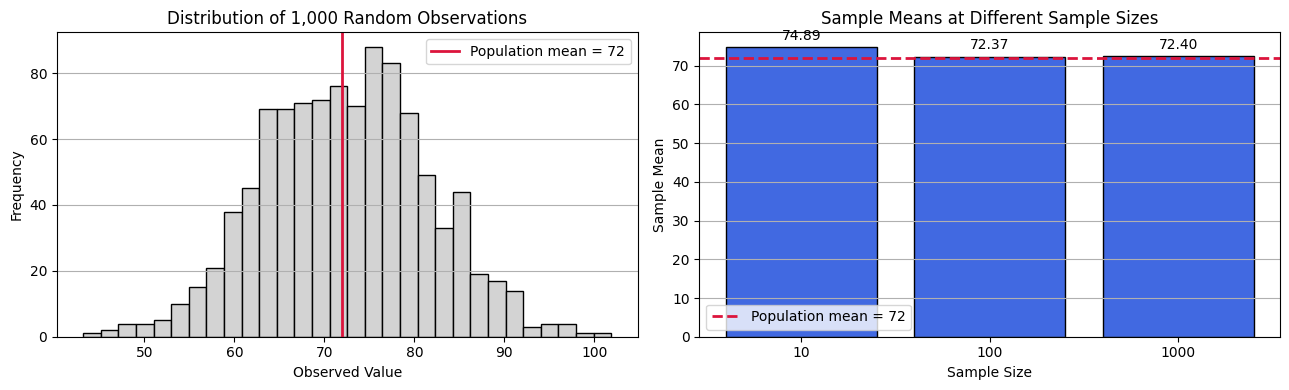

In [32]:
sample_sizes = [10, 100, 1000]
sample_means = [
    np.mean(random_sample[:sample_size])
    for sample_size in sample_sizes
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# First graph: histogram of the random sample
axes[0].hist(
    random_sample,
    bins=30,
    color="lightgray",
    edgecolor="black"
)

axes[0].axvline(
    population_mean,
    color="crimson",
    linewidth=2,
    label=f"Population mean = {population_mean}"
)

axes[0].set_title("Distribution of 1,000 Random Observations")
axes[0].set_xlabel("Observed Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y")

# Second graph: compare sample means at different sample sizes
bars = axes[1].bar(
    [str(size) for size in sample_sizes],
    sample_means,
    color="royalblue",
    edgecolor="black"
)

axes[1].axhline(
    population_mean,
    color="crimson",
    linewidth=2,
    linestyle="--",
    label=f"Population mean = {population_mean}"
)

axes[1].bar_label(bars, fmt="%.2f", padding=3)

axes[1].set_title("Sample Means at Different Sample Sizes")
axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Mean")
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Section Conclusion

The random sample example showed how a sample can be used to estimate information about a larger population. The sample means from different sample sizes were compared with the population mean. Larger samples usually give an estimate that is closer to the true population mean.

## Conclusion / Reflection

Joint probability distributions, correlation, dependence, and random samples all demonstrate different ways that probability can be used to understand data. The joint probability distribution showed how two random variables can be studied together, while correlation showed the strength of a linear relationship between two variables. It was interesting how the nonlinear graph demonstrated that two variables can still be dependent even when their correlation is close to 0.

The random sample section also showed how a sample can be used to represent a larger population. Now I understand that larger samples are generally more reliable because their sample means are often closer to the true population mean. Python made it easier to see the numerical results and the graphs at the same time.